# Grover's Algorithm – 10-Qubit Implementation

**Name:** Abhijit Zende  
**ID:** 26PGAI0009

In [1]:
!pip install qiskit qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.2 MB/s eta 0:00:00


In [2]:
import math
import warnings
warnings.filterwarnings('ignore')

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

print("All imports successful ✓")

All imports successful ✓


In [3]:
n = 10
targets = ["0110011010", "1101010001"]

N = 2 ** n
M = len(targets)

print(f"Search space : 2^{n} = {N} states")
print(f"Marked states ({M}):")
for s in targets:
    print(f"  '{s}'  →  decimal {int(s, 2)}")

# exact formula: k_opt = floor(pi / (4 * arcsin(sqrt(M/N))))
theta = math.asin(math.sqrt(M / N))
k_opt = math.floor(math.pi / (4 * theta))
ITER_COUNTS = [1, 3, 5, 10, k_opt]

print(f"\nθ = arcsin(√(M/N)) = {theta:.6f} rad")
print(f"k_opt = ⌊π/(4θ)⌋ = {k_opt}")
print(f"Iteration counts to study: {ITER_COUNTS}")

print(f"\n{'k':>5}  {'P(marked) theory':>18}")
print("─" * 26)
for k in ITER_COUNTS:
    p = math.sin((2 * k + 1) * theta) ** 2
    flag = "  ← optimal" if k == k_opt else ""
    print(f"{k:>5}  {p:>18.4f}{flag}")

Search space : 2^10 = 1024 states
Marked states (2):
  '0110011010'  →  decimal 410
  '1101010001'  →  decimal 849

θ = arcsin(√(M/N)) = 0.044209 rad
k_opt = ⌊π/(4θ)⌋ = 17
Iteration counts to study: [1, 3, 5, 10, 17]

    k    P(marked) theory
──────────────────────────
    1              0.0175
    3              0.0927
    5              0.2184
   10              0.6410
   17              0.9994  ← optimal


## Oracle

For each marked state, flip the zero-bit qubits so the target maps to |11…1⟩, apply MCZ (phase flip via H–MCX–H), then restore.

In [4]:
def build_oracle(n, targets):
    qc = QuantumCircuit(n)
    for t in targets:
        # Qiskit bitstring convention: qubit i <-> character at position n-1-i
        zeros = [i for i in range(n) if t[n - 1 - i] == '0']
        qc.x(zeros)
        qc.h(n - 1)
        qc.mcx(list(range(n - 1)), n - 1)
        qc.h(n - 1)
        qc.x(zeros)
    return qc

oracle = build_oracle(n, targets)
print(f"Oracle  |  depth: {oracle.depth()}  |  gates: {dict(oracle.count_ops())}")

Oracle  |  depth: 8  |  gates: {'x': 20, 'h': 4, 'mcx': 2}


## Diffusion Operator

Implements 2|s⟩⟨s| − I via H → X → MCZ → X → H.

In [7]:
def build_diffusion(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    # MCZ = H · MCX · H on last qubit
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

diff = build_diffusion(n)
print(f"Diffuser  |  depth: {diff.depth()}  |  gates: {dict(diff.count_ops())}")

Diffuser  |  depth: 7  |  gates: {'h': 22, 'x': 20, 'mcx': 1}


## Grover Circuit

In [8]:
def grover_circuit(n, targets, k):
    qc = QuantumCircuit(n, n)
    qc.h(range(n))  # equal superposition over all 1024 states
    qc.barrier(label='Init |s⟩')

    oracle = build_oracle(n, targets).to_gate(label='Oracle')
    diff   = build_diffusion(n).to_gate(label='Diffusion')

    for i in range(k):
        qc.append(oracle, range(n))
        qc.append(diff,   range(n))
        qc.barrier(label=f'Iter {i+1}')

    qc.measure(range(n), range(n))
    return qc

print(grover_circuit(n, targets, 1).draw('text'))

      ┌───┐ Init |s⟩ ┌─────────┐┌────────────┐ Iter 1 ┌─┐                     »
 q_0: ┤ H ├────░─────┤0        ├┤0           ├───░────┤M├─────────────────────»
      ├───┤    ░     │         ││            │   ░    └╥┘┌─┐                  »
 q_1: ┤ H ├────░─────┤1        ├┤1           ├───░─────╫─┤M├──────────────────»
      ├───┤    ░     │         ││            │   ░     ║ └╥┘┌─┐               »
 q_2: ┤ H ├────░─────┤2        ├┤2           ├───░─────╫──╫─┤M├───────────────»
      ├───┤    ░     │         ││            │   ░     ║  ║ └╥┘┌─┐            »
 q_3: ┤ H ├────░─────┤3        ├┤3           ├───░─────╫──╫──╫─┤M├────────────»
      ├───┤    ░     │         ││            │   ░     ║  ║  ║ └╥┘┌─┐         »
 q_4: ┤ H ├────░─────┤4        ├┤4           ├───░─────╫──╫──╫──╫─┤M├─────────»
      ├───┤    ░     │  Oracle ││  Diffusion │   ░     ║  ║  ║  ║ └╥┘┌─┐      »
 q_5: ┤ H ├────░─────┤5        ├┤5           ├───░─────╫──╫──╫──╫──╫─┤M├──────»
      ├───┤    ░     │         ││       

## Simulation

Running for k = 1, 3, 5, 10 iterations. Red bars are the marked states.

In [9]:
sim     = AerSimulator()
shots   = 8192
results = {}

print(f"Running Grover search ({shots} shots per run)...")
print(f"\n{'k':>5}  {'P(theory)':>10}  {'P(sim)':>10}  {'Note'}")
print("─" * 42)

for k in ITER_COUNTS:
    qc      = grover_circuit(n, targets, k)
    counts  = sim.run(transpile(qc, sim), shots=shots).result().get_counts()
    results[k] = counts

    p_theory = math.sin((2 * k + 1) * theta) ** 2
    p_sim    = sum(counts.get(s, 0) for s in targets) / shots
    flag     = "  ← optimal" if k == k_opt else ""
    print(f"{k:>5}  {p_theory:>10.4f}  {p_sim:>10.4f}{flag}")

print("\nDone ✓")

Running Grover search (8192 shots per run)...

    k   P(theory)      P(sim)  Note
──────────────────────────────────────────
    1      0.0175      0.0197
    3      0.0927      0.0961
    5      0.2184      0.2196
   10      0.6410      0.6436
   17      0.9994      0.9993  ← optimal

Done ✓


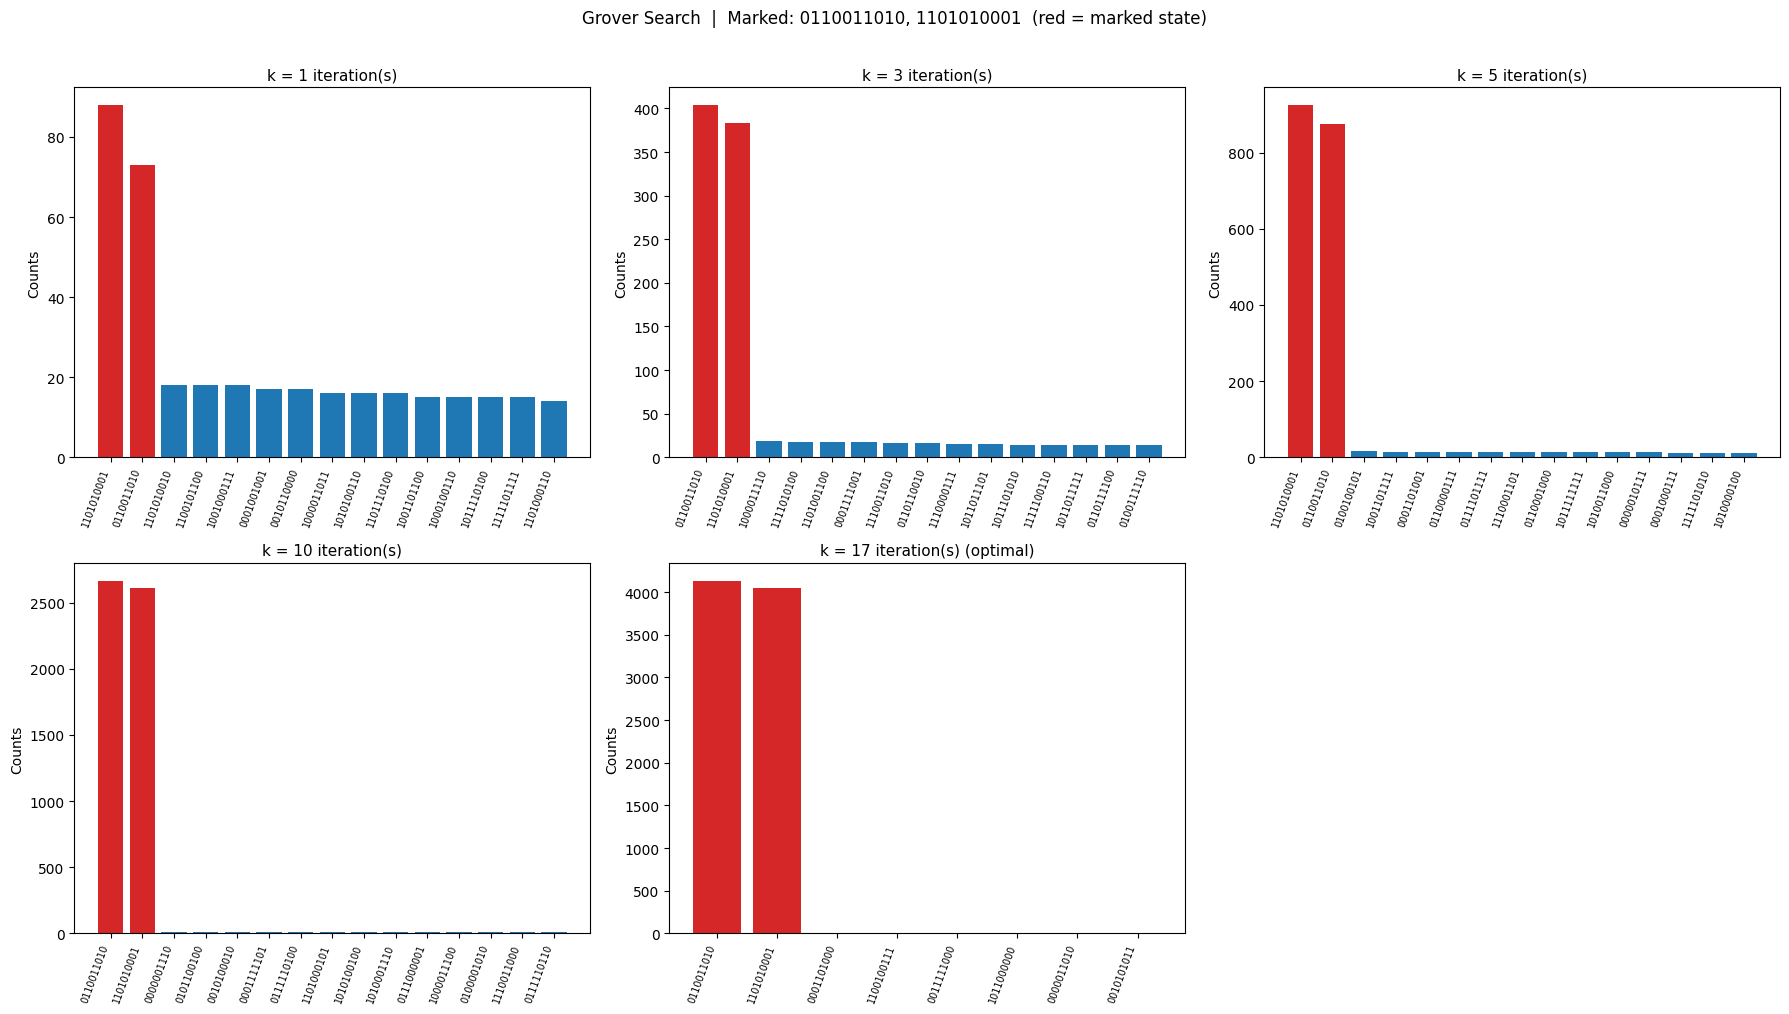

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, k in enumerate(ITER_COUNTS):
    counts = results[k]
    top    = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:15])
    states = list(top.keys())
    vals   = list(top.values())
    colors = ['#d62728' if s in targets else '#1f77b4' for s in states]

    axes[idx].bar(range(len(states)), vals, color=colors)
    axes[idx].set_xticks(range(len(states)))
    axes[idx].set_xticklabels(states, rotation=70, ha='right', fontsize=7)
    note = ' (optimal)' if k == k_opt else ''
    axes[idx].set_title(f'k = {k} iteration(s){note}', fontsize=11)
    axes[idx].set_ylabel('Counts')

axes[-1].axis('off')  # hide unused 6th panel

fig.suptitle(
    'Grover Search  |  Marked: 0110011010, 1101010001  (red = marked state)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('grover_results.png', dpi=150, bbox_inches='tight')
plt.show()

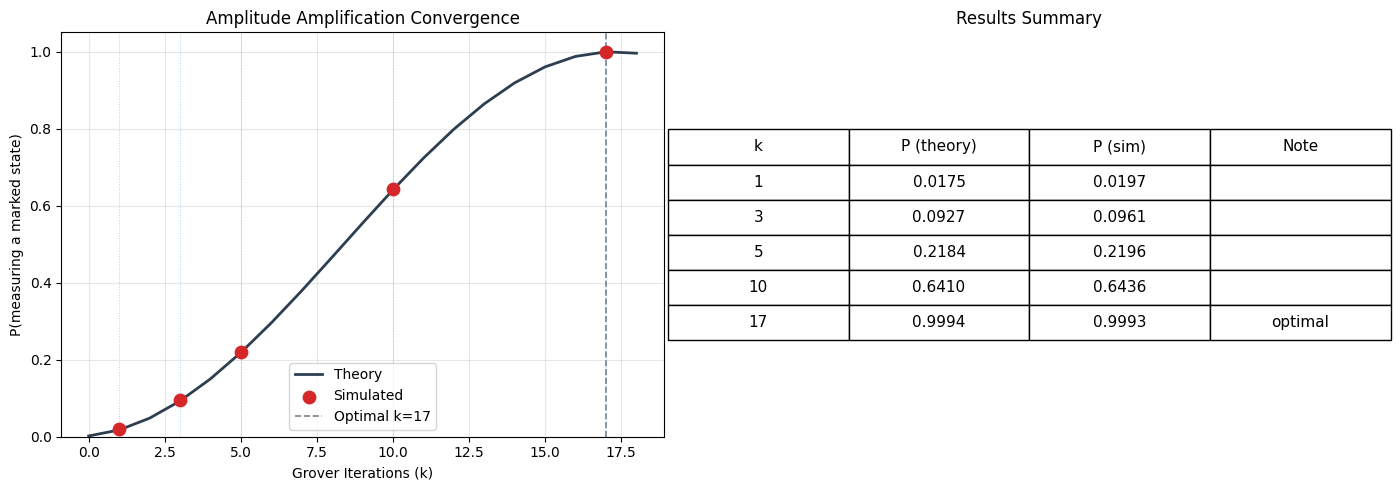


At k=17 (optimal):  P(marked) = 0.9993  (99.9%)
Algorithm: SUCCEEDED ✓


In [11]:
# Amplitude amplification convergence curve
all_k   = list(range(k_opt + 2))
p_curve = [math.sin((2 * k + 1) * theta) ** 2 for k in all_k]
sim_pts = [sum(results[k].get(s, 0) for s in targets) / shots for k in ITER_COUNTS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: convergence curve
ax = axes[0]
ax.plot(all_k, p_curve, '-', color='#2c3e50', linewidth=2, label='Theory')
ax.scatter(ITER_COUNTS, sim_pts, color='#d62728', s=80, zorder=3, label='Simulated')
ax.axvline(k_opt, color='gray', linestyle='--', linewidth=1.2, label=f'Optimal k={k_opt}')
for k in ITER_COUNTS:
    ax.axvline(k, color='#3498db', linestyle=':', linewidth=0.7, alpha=0.4)
ax.set_xlabel('Grover Iterations (k)')
ax.set_ylabel('P(measuring a marked state)')
ax.set_title('Amplitude Amplification Convergence')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(alpha=0.3)

# Right: summary table
ax2 = axes[1]
ax2.axis('off')
headers = ['k', 'P (theory)', 'P (sim)', 'Note']
rows = []
for k in ITER_COUNTS:
    p_th = math.sin((2 * k + 1) * theta) ** 2
    p_s  = sum(results[k].get(s, 0) for s in targets) / shots
    rows.append([str(k), f'{p_th:.4f}', f'{p_s:.4f}', 'optimal' if k == k_opt else ''])
tbl = ax2.table(cellText=rows, colLabels=headers, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2.0)
ax2.set_title('Results Summary')

plt.tight_layout()
plt.savefig('grover_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# Final verdict
p_final = sum(results[k_opt].get(s, 0) for s in targets) / shots
print(f"\nAt k={k_opt} (optimal):  P(marked) = {p_final:.4f}  ({p_final*100:.1f}%)")
print(f"Algorithm: {'SUCCEEDED ✓' if p_final > 0.8 else 'needs review ✗'}")